# Crop Pest LightGBM Classifier
13-type feature fusion (2836 dims): HSV Histogram, Hu Moments, LBP, HOG, Contour Geometry, GLCM Haralick, Color Moments, Multi-scale LBP, Gabor, Zernike, Fourier, Canny, Color Correlogram

In [7]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path().resolve().parent))

import os
import logging
import pickle
import cv2
import numpy as np
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import lightgbm as lgb

logging.basicConfig(level=logging.WARNING, format='[%(name)s] %(levelname)s: %(message)s')

from shared import (
    resolve_paths, yolo_box_to_xyxy, clamp_xyxy,
    plot_confusion_matrix, save_classification_report,
)
from feature_extraction import extract_features, create_hog_descriptor, FEATURE_DIM, EXTRACTED_DIMS

PROJECT_ROOT, DATA_ROOT, OUT_ROOT = resolve_paths()

FEATURE_CACHE_DIR = Path(OUT_ROOT) / "lightgbm_cache"
FEATURE_CACHE_DIR.mkdir(parents=True, exist_ok=True)

PROJECT_ROOT: f:\github\agro-pest
DATA_ROOT:    f:\github\agro-pest\archive
OUT_ROOT:     f:\github\agro-pest\runs
Data exists:  True


In [8]:
CONFIG = {
    "YOLO_ROOT": DATA_ROOT,
    "OUT_ROOT": OUT_ROOT,

    "CLASS_NAMES": [
        "Ants", "Bees", "Beetles", "Caterpillars", "Earthworms", "Earwigs",
        "Grasshoppers", "Moths", "Slugs", "Snails", "Wasps", "Weevils",
    ],

    "CROP_MARGIN_RATIO": 0.05,
    "MIN_CROP_SIZE": 20,
    "RESIZE_TO": (64, 64),

    "LGBM_NUM_LEAVES": 31,
    "LGBM_MAX_DEPTH": -1,
    "LGBM_LEARNING_RATE": 0.05,
    "LGBM_N_ESTIMATORS": 500,
    "LGBM_SUBSAMPLE": 0.8,
    "LGBM_COLSAMPLE_BYTREE": 0.8,
    "LGBM_REG_ALPHA": 0.1,
    "LGBM_REG_LAMBDA": 0.1,
    "LGBM_MIN_CHILD_SAMPLES": 20,
    "LGBM_EARLY_STOPPING": 50,
    "LGBM_VERBOSE_EVAL": 50,
}

cfg = CONFIG

In [9]:
def load_paths(folder):
    images_folder = os.path.join(folder, "images")
    labels_folder = os.path.join(folder, "labels")
    img_exts = {'.jpg', '.jpeg', '.png', '.bmp'}
    image_paths = sorted(
        [os.path.join(images_folder, f) for f in os.listdir(images_folder)
         if os.path.splitext(f)[1].lower() in img_exts]
    )
    label_paths = []
    valid_image_paths = []
    for img_path in image_paths:
        stem = os.path.splitext(os.path.basename(img_path))[0]
        lbl = os.path.join(labels_folder, stem + ".txt")
        if os.path.exists(lbl):
            valid_image_paths.append(img_path)
            label_paths.append(lbl)
    return valid_image_paths, label_paths


def extract_dataset_features(image_paths, label_paths, hog_desc, margin_ratio=0.05, min_crop=20, resize_to=(64, 64), desc="Extracting"):
    X = []
    y = []
    dim_mismatch = 0
    for img_path, label_path in tqdm(zip(image_paths, label_paths), total=len(image_paths), desc=desc):
        img = cv2.imread(img_path)
        if img is None:
            continue
        H, W = img.shape[:2]
        with open(label_path, "r") as f:
            lines = [ln for ln in f.read().strip().splitlines() if ln.strip()]
        for line in lines:
            cid, xyxy = yolo_box_to_xyxy(line, W, H)
            if cid is None or xyxy is None:
                continue
            xyxy = clamp_xyxy(xyxy, W, H, margin_ratio=margin_ratio)
            if xyxy is None:
                continue
            x1, y1, x2, y2 = xyxy
            roi = img[y1:y2, x1:x2]
            if roi.size == 0 or roi.shape[0] < min_crop or roi.shape[1] < min_crop:
                continue
            roi = cv2.resize(roi, resize_to)
            feature = extract_features(roi, hog_desc)
            if feature.shape[0] != FEATURE_DIM:
                dim_mismatch += 1
                continue
            X.append(feature)
            y.append(cid)
        del img
    if dim_mismatch > 0:
        print(f"WARNING: {dim_mismatch} samples skipped due to dimension mismatch (expected {FEATURE_DIM})")
    return np.array(X), np.array(y)


def save_features(cache_path, X, y):
    data = {"X": X, "y": y, "dim": X.shape[1]}
    with open(cache_path, "wb") as f:
        pickle.dump(data, f)
    print(f"Features saved to {cache_path}")


def load_features(cache_path):
    with open(cache_path, "rb") as f:
        data = pickle.load(f)
    cached_dim = data.get("dim", None)
    if cached_dim is not None and cached_dim != FEATURE_DIM:
        print(f"Cache dimension mismatch: cached={cached_dim}, current={FEATURE_DIM}. Invalidating cache.")
        return None, None
    print(f"Features loaded from {cache_path}")
    return data.get("X"), data.get("y")

In [10]:
USE_CACHE = True
cache_file = FEATURE_CACHE_DIR / "train_features.pkl"

X_train = None
if USE_CACHE and cache_file.exists():
    X_train, y_train = load_features(cache_file)

if X_train is None:
    train_folder = os.path.join(cfg["YOLO_ROOT"], "train")
    train_image_paths, train_label_paths = load_paths(train_folder)
    hog_desc = create_hog_descriptor()
    X_train, y_train = extract_dataset_features(
        train_image_paths, train_label_paths, hog_desc,
        margin_ratio=cfg["CROP_MARGIN_RATIO"],
        min_crop=cfg["MIN_CROP_SIZE"],
        resize_to=cfg["RESIZE_TO"],
        desc="Train",
    )
    save_features(cache_file, X_train, y_train)
else:
    hog_desc = create_hog_descriptor()

print(f"Training samples: {len(X_train)}, Feature dim: {X_train.shape[1]}")

unique, counts = np.unique(y_train, return_counts=True)
print("Class distribution:", dict(zip(unique, counts)))

Features loaded from f:\github\agro-pest\runs\lightgbm_cache\train_features.pkl
Training samples: 15255, Feature dim: 2836
Class distribution: {0: 2221, 1: 1592, 2: 1058, 3: 1733, 4: 1083, 5: 1182, 6: 1071, 7: 1062, 8: 918, 9: 1196, 10: 1167, 11: 972}


In [11]:
from sklearn.model_selection import train_test_split
import joblib

USE_CACHE = True
model_cache_file = FEATURE_CACHE_DIR / "lightgbm_model.pkl"

cached_data = None
if USE_CACHE and model_cache_file.exists():
    cached_data = joblib.load(model_cache_file)
    if isinstance(cached_data, tuple) and len(cached_data) == 3:
        model, scaler, cached_n_feat = cached_data
        if cached_n_feat != FEATURE_DIM:
            print(f"Model cache dimension mismatch: cached={cached_n_feat}, current={FEATURE_DIM}. Retraining...")
            cached_data = None
        else:
            print(f"Model loaded from {model_cache_file}")
    else:
        os.remove(model_cache_file)
        print(f"Deleted old cache file {model_cache_file}, will retrain...")

if cached_data is None:
    X_train_split, X_val, y_train_split, y_val = train_test_split(
        X_train, y_train, test_size=0.15, random_state=42, stratify=y_train
    )
    print(f"Train split: {len(X_train_split)}, Val split: {len(X_val)}")

    scaler = StandardScaler()
    X_train_split = scaler.fit_transform(X_train_split)
    X_val = scaler.transform(X_val)

    model = lgb.LGBMClassifier(
        n_estimators=cfg["LGBM_N_ESTIMATORS"],
        learning_rate=cfg["LGBM_LEARNING_RATE"],
        num_leaves=cfg["LGBM_NUM_LEAVES"],
        max_depth=cfg["LGBM_MAX_DEPTH"],
        subsample=cfg["LGBM_SUBSAMPLE"],
        colsample_bytree=cfg["LGBM_COLSAMPLE_BYTREE"],
        reg_alpha=cfg["LGBM_REG_ALPHA"],
        reg_lambda=cfg["LGBM_REG_LAMBDA"],
        min_child_samples=cfg["LGBM_MIN_CHILD_SAMPLES"],
        class_weight="balanced",
        n_jobs=-1,
        random_state=42,
        verbose=-1,
    )

    model.fit(
        X_train_split, y_train_split,
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(cfg["LGBM_EARLY_STOPPING"]),
            lgb.log_evaluation(cfg["LGBM_VERBOSE_EVAL"]),
        ],
    )
    print("LightGBM training complete")

    joblib.dump((model, scaler, FEATURE_DIM), model_cache_file)
    print(f"Model saved to {model_cache_file}")

Train split: 12966, Val split: 2289
Training until validation scores don't improve for 50 rounds
[50]	valid_0's multi_logloss: 1.17583
[100]	valid_0's multi_logloss: 0.92453
[150]	valid_0's multi_logloss: 0.798207
[200]	valid_0's multi_logloss: 0.727192
[250]	valid_0's multi_logloss: 0.683827
[300]	valid_0's multi_logloss: 0.658897
[350]	valid_0's multi_logloss: 0.64397
[400]	valid_0's multi_logloss: 0.635387
[450]	valid_0's multi_logloss: 0.629581
[500]	valid_0's multi_logloss: 0.627105
Did not meet early stopping. Best iteration is:
[500]	valid_0's multi_logloss: 0.627105
LightGBM training complete
Model saved to f:\github\agro-pest\runs\lightgbm_cache\lightgbm_model.pkl


Features loaded from f:\github\agro-pest\runs\lightgbm_cache\test_features.pkl
Test samples: 689
Test accuracy: 0.6096
              precision    recall  f1-score   support

        Ants     0.6395    0.6322    0.6358        87
        Bees     0.5522    0.8409    0.6667        44
     Beetles     0.4186    0.4091    0.4138        44
Caterpillars     0.4853    0.7097    0.5764        93
  Earthworms     0.6190    0.6500    0.6341        40
     Earwigs     0.5135    0.2603    0.3455        73
Grasshoppers     0.5417    0.4727    0.5049        55
       Moths     0.8333    0.7447    0.7865        47
       Slugs     0.5556    0.2941    0.3846        51
      Snails     0.7222    0.7800    0.7500        50
       Wasps     0.7600    0.8085    0.7835        47
     Weevils     0.8070    0.7931    0.8000        58

    accuracy                         0.6096       689
   macro avg     0.6207    0.6163    0.6068       689
weighted avg     0.6120    0.6096    0.5981       689



d:\python-3.11\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


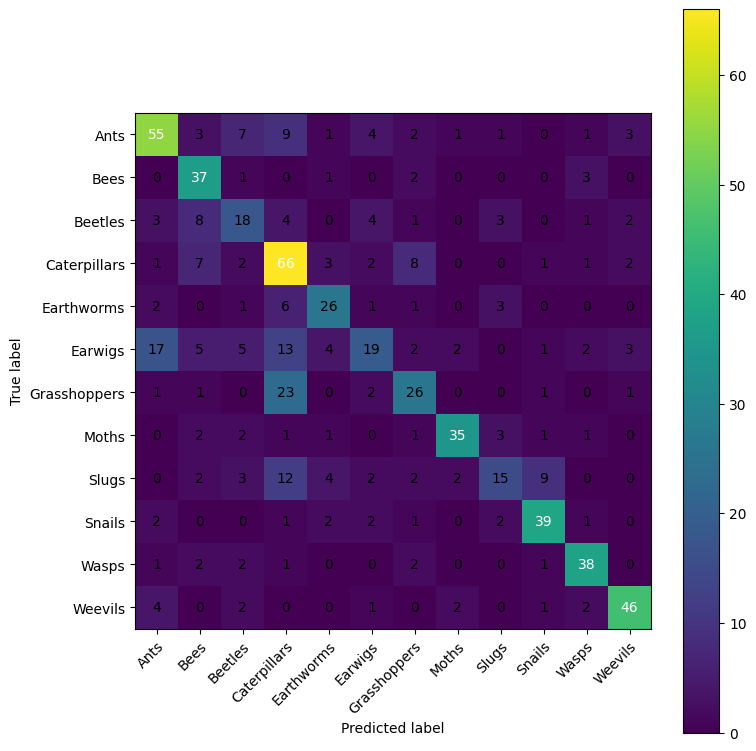


=== DONE (LightGBM) ===


In [12]:
USE_CACHE = True
cache_file_test = FEATURE_CACHE_DIR / "test_features.pkl"

X_test = None
if USE_CACHE and cache_file_test.exists():
    X_test, y_test = load_features(cache_file_test)

if X_test is None:
    test_folder = os.path.join(cfg["YOLO_ROOT"], "test")
    test_image_paths, test_label_paths = load_paths(test_folder)
    X_test, y_test = extract_dataset_features(
        test_image_paths, test_label_paths, hog_desc,
        margin_ratio=cfg["CROP_MARGIN_RATIO"],
        min_crop=cfg["MIN_CROP_SIZE"],
        resize_to=cfg["RESIZE_TO"],
        desc="Test",
    )
    save_features(cache_file_test, X_test, y_test)

print(f"Test samples: {len(X_test)}")

X_test_scaled = scaler.transform(X_test)
y_pred = model.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {acc:.4f}")
print(classification_report(y_test, y_pred, target_names=cfg["CLASS_NAMES"], digits=4))

cm = confusion_matrix(y_test, y_pred)
plot_confusion_matrix(cm, cfg["CLASS_NAMES"], os.path.join(cfg["OUT_ROOT"], "lightgbm_cm_test.png"))

save_classification_report(
    Path(cfg["OUT_ROOT"]), y_test, y_pred, cfg["CLASS_NAMES"]
)

print("\n=== DONE (LightGBM) ===")

C:\Users\manafeng-local\AppData\Local\Temp\ipykernel_24980\3753998896.py:19: UserWarning: Glyph 39068 (\N{CJK UNIFIED IDEOGRAPH-989C}) missing from current font.
  plt.tight_layout()
C:\Users\manafeng-local\AppData\Local\Temp\ipykernel_24980\3753998896.py:19: UserWarning: Glyph 33394 (\N{CJK UNIFIED IDEOGRAPH-8272}) missing from current font.
  plt.tight_layout()
C:\Users\manafeng-local\AppData\Local\Temp\ipykernel_24980\3753998896.py:19: UserWarning: Glyph 30456 (\N{CJK UNIFIED IDEOGRAPH-76F8}) missing from current font.
  plt.tight_layout()
C:\Users\manafeng-local\AppData\Local\Temp\ipykernel_24980\3753998896.py:19: UserWarning: Glyph 20851 (\N{CJK UNIFIED IDEOGRAPH-5173}) missing from current font.
  plt.tight_layout()
C:\Users\manafeng-local\AppData\Local\Temp\ipykernel_24980\3753998896.py:19: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from current font.
  plt.tight_layout()
C:\Users\manafeng-local\AppData\Local\Temp\ipykernel_24980\3753998896.py:19: UserWarn

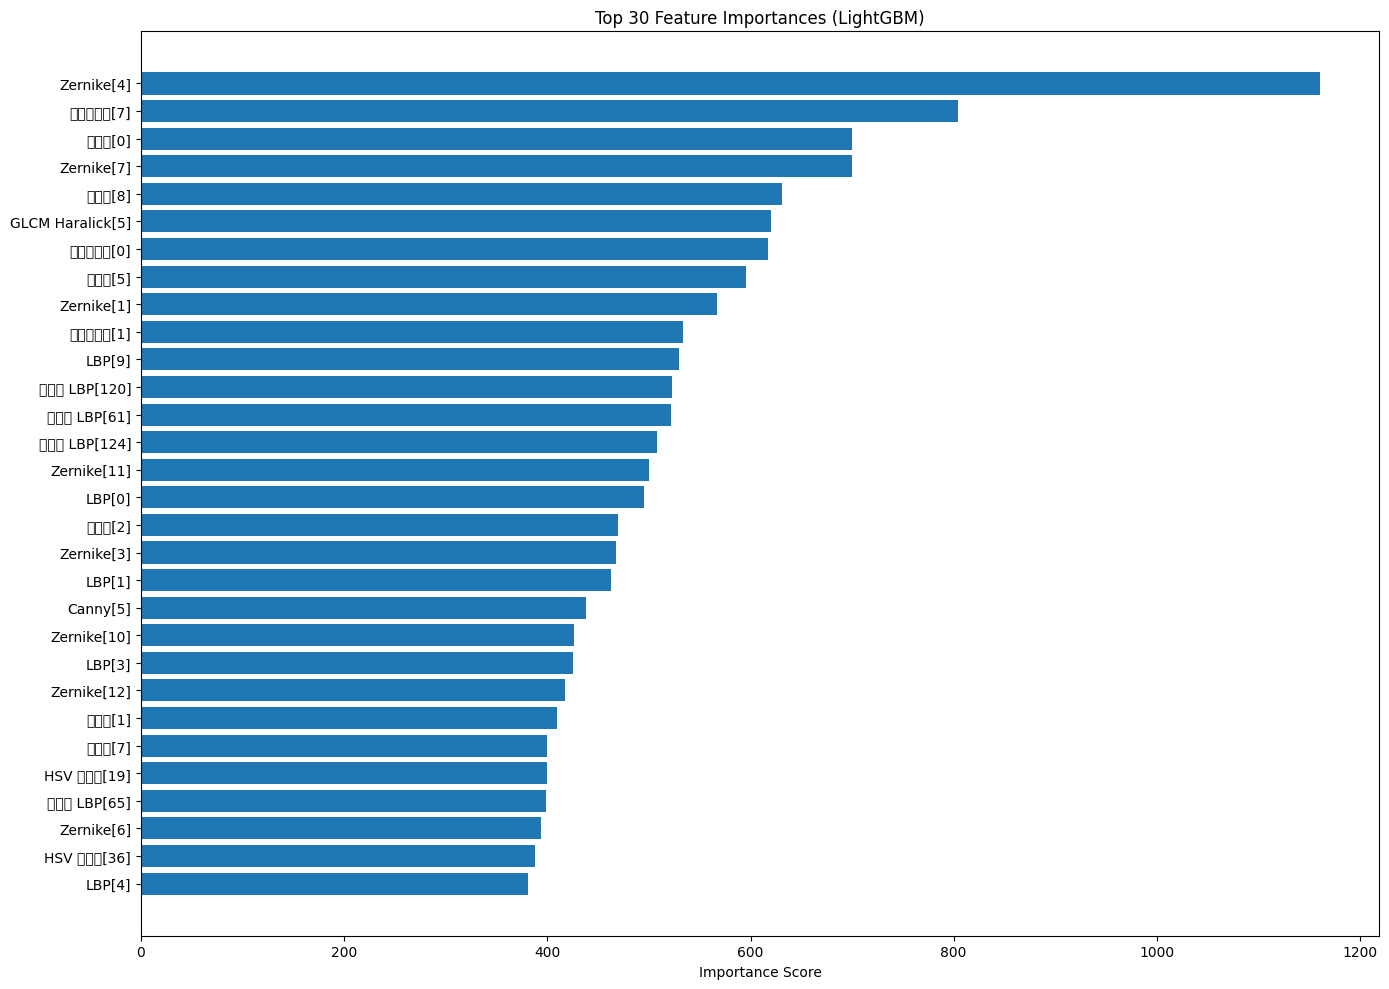

Top 30 important features:
  1. Zernike[4]: 1161.00
  2. 颜色相关图[7]: 804.00
  3. 颜色矩[0]: 700.00
  4. Zernike[7]: 700.00
  5. 颜色矩[8]: 631.00
  6. GLCM Haralick[5]: 620.00
  7. 颜色相关图[0]: 617.00
  8. 颜色矩[5]: 596.00
  9. Zernike[1]: 567.00
  10. 颜色相关图[1]: 534.00
  11. LBP[9]: 530.00
  12. 多尺度 LBP[120]: 523.00
  13. 多尺度 LBP[61]: 522.00
  14. 多尺度 LBP[124]: 508.00
  15. Zernike[11]: 500.00
  16. LBP[0]: 495.00
  17. 颜色矩[2]: 470.00
  18. Zernike[3]: 468.00
  19. LBP[1]: 463.00
  20. Canny[5]: 438.00
  21. Zernike[10]: 426.00
  22. LBP[3]: 425.00
  23. Zernike[12]: 417.00
  24. 颜色矩[1]: 410.00
  25. 颜色矩[7]: 400.00
  26. HSV 直方图[19]: 400.00
  27. 多尺度 LBP[65]: 399.00
  28. Zernike[6]: 394.00
  29. HSV 直方图[36]: 388.00
  30. LBP[4]: 381.00


In [13]:
import matplotlib.pyplot as plt

feature_importance = model.feature_importances_

feat_groups = []
for name, dim in EXTRACTED_DIMS.items():
    for i in range(dim):
        feat_groups.append(f"{name}[{i}]")

top_n = 30
indices = np.argsort(feature_importance)[::-1][:top_n]

plt.figure(figsize=(14, 10))
plt.title(f"Top {top_n} Feature Importances (LightGBM)")
plt.barh(range(top_n), feature_importance[indices], align="center")
plt.yticks(range(top_n), [feat_groups[i] for i in indices])
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(cfg["OUT_ROOT"], "lightgbm_feature_importance.png"), dpi=200)
plt.show()

print(f"Top {top_n} important features:")
for i, idx in enumerate(indices):
    print(f"  {i+1}. {feat_groups[idx]}: {feature_importance[idx]:.2f}")